In [36]:
#import python libraries

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [18]:
#import csv dataset
df = pd.read_csv('Diwali_Sales_Data.csv',encoding='latin-1')


In [11]:
# No of Rows and columns
df.shape

(11251, 15)

In [12]:
#Top 5 Rows
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11239 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11239 non-null  int64  
 1   Cust_name         11239 non-null  object 
 2   Product_ID        11239 non-null  object 
 3   Gender            11239 non-null  object 
 4   Age Group         11239 non-null  object 
 5   Age               11239 non-null  int64  
 6   Marital_Status    11239 non-null  int64  
 7   State             11239 non-null  object 
 8   Zone              11239 non-null  object 
 9   Occupation        11239 non-null  object 
 10  Product_Category  11239 non-null  object 
 11  Orders            11239 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.2+ MB


In [19]:
#drop blank columns
df.drop(['Status','unnamed1'],axis=1,inplace=True)

In [20]:
#check for nulls
df.isna().sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [23]:
#drop null vlues
df.dropna(inplace=True)
df.isna().sum()

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

In [28]:
#change data type
df['Amount'] = df['Amount'].astype(int)
df['Amount'].dtype

dtype('int64')

In [31]:
#replace 0 and 1 binary with yes and no for marital status
df['Marital_Status'] = df['Marital_Status'].replace({0:"No",1:"Yes"}) 
df['Marital_Status']

0         No
1        Yes
2        Yes
3         No
4        Yes
        ... 
11246    Yes
11247     No
11248     No
11249     No
11250     No
Name: Marital_Status, Length: 11239, dtype: object

In [35]:
# Statistics of Key columns
df[['Amount','Age','Orders']].describe()

,Amount,Age,Orders
count,11239.000000,11239.000000,11239.000000
mean,9453.610553,35.410357,2.489634
std,5222.355168,12.753866,1.114967
min,188.000000,12.000000,1.000000
25%,5443.000000,27.000000,2.000000
50%,8109.000000,33.000000,2.000000
75%,12675.000000,43.000000,3.000000
max,23952.000000,92.000000,4.000000


# Exploratory Data Analysis

## Gender

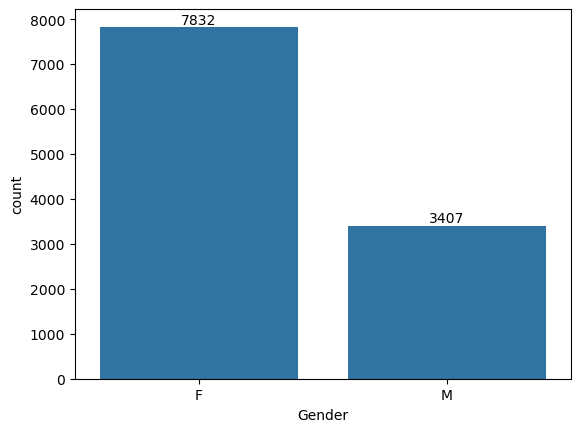

In [50]:
#plotting countplot for gender count
ax = sns.countplot(x='Gender',data=df)
for bars in ax.containers:
   ax.bar_label(bars)

## Age


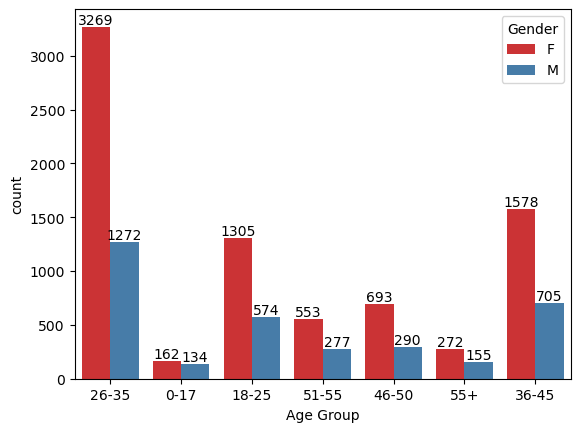

In [91]:
# Gender Count in Different Age Groups
ax = sns.countplot(data=df,x='Age Group',hue='Gender',palette='Set1')
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

<Axes: xlabel='Age Group', ylabel='Amount'>

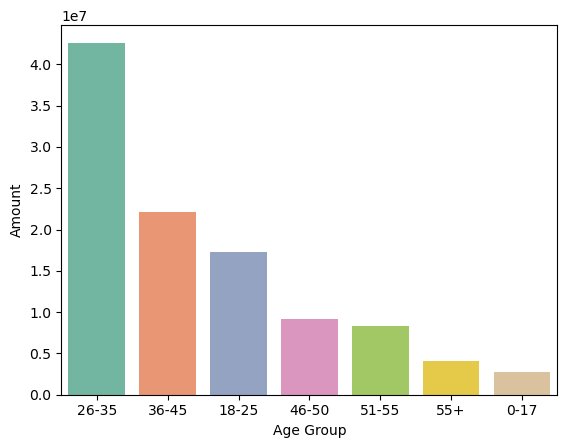

In [144]:
## Total Amount vs Age Group
amount_by_age_group =  df.groupby('Age Group')['Amount'].sum().sort_values(ascending=False).reset_index()
sns.barplot(x = 'Age Group',y= 'Amount' ,data = amount_by_age_group,hue='Age Group',palette='Set2')

*From above graphs we can see that most of the buyers are of age group between 26-35 yrs female*

## State

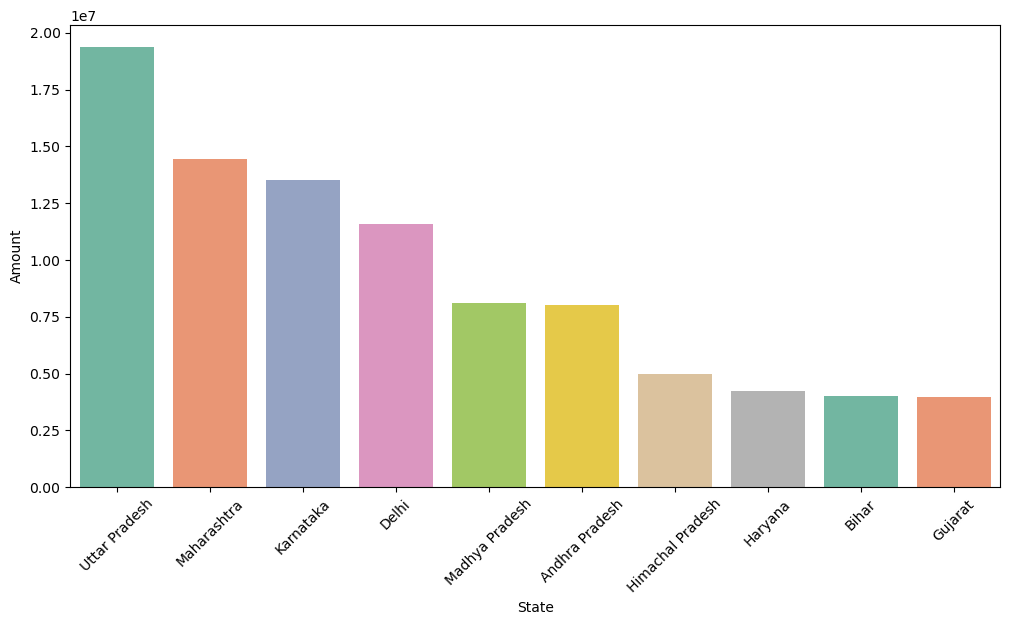

In [101]:
# Top 10 states by Sales amount
Top_10_States = df.groupby('State')['Amount'].sum().sort_values(ascending=False).reset_index().head(10)
plt.figure(figsize=(12,6))
sns.barplot(data=Top_10_States,x='State',y='Amount',hue ='State',palette='Set2')
plt.xticks(rotation=45)
plt.show()

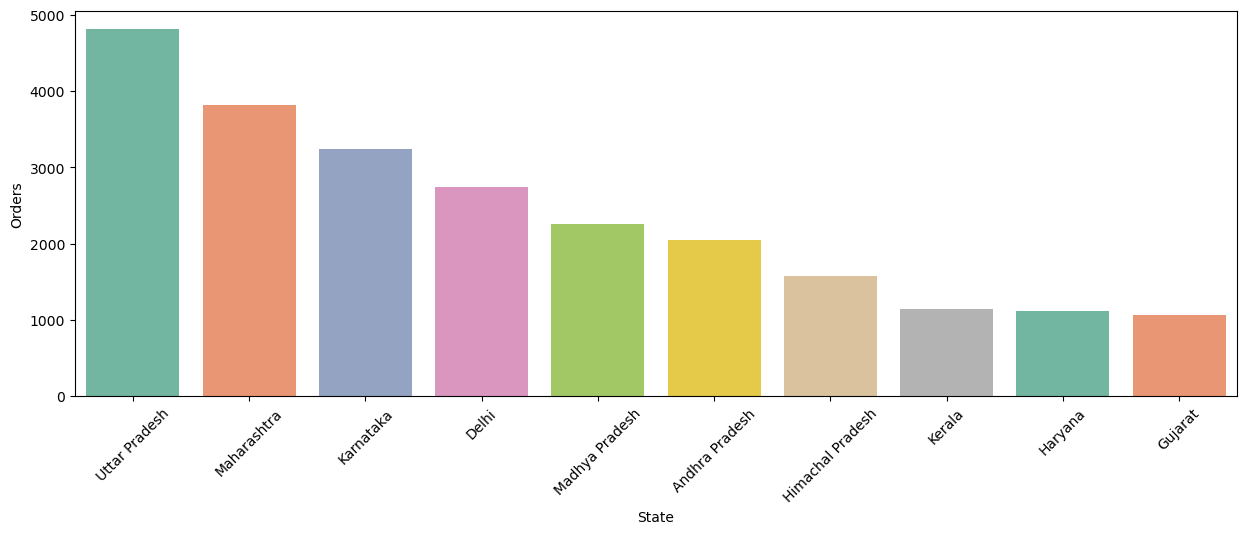

In [76]:
#Top 10 states by order
Top_10_States = df.groupby(['State'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

plt.figure(figsize=(15,5))
sns.barplot(data=Top_10_States,x='State',y='Orders',hue ='State',palette='Set2')
plt.xticks(rotation=45)
plt.show()

*From above graphs we can see that most of the orders & total sales/amount are from Uttar Pradesh, Maharashtra and Karnataka respectively*

## Marital Status

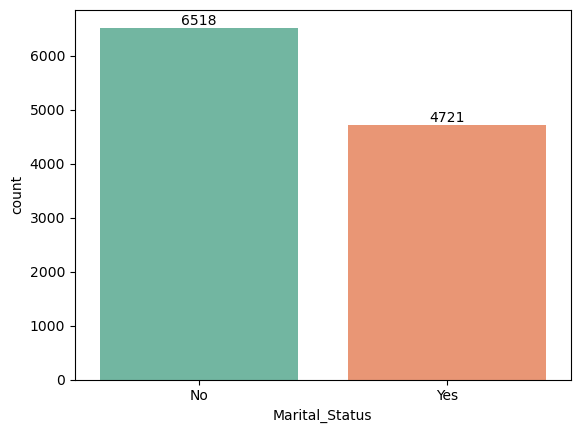

In [106]:
# Count of Marital Status
ax = sns.countplot(data=df,x='Marital_Status',hue='Marital_Status',palette='Set2')
for bars in ax.containers:
    ax.bar_label(bars)

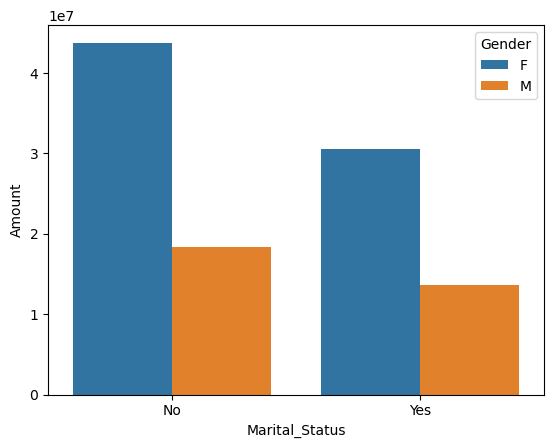

In [109]:
#Marital Status by Gender
Purchasing_Status = df.groupby(['Marital_Status', 'Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sns.barplot(data = Purchasing_Status , x = 'Marital_Status',y= 'Amount', hue='Gender')
plt.show()

*From above graphs we can see that most of the buyers are married (women) and they have high purchasing power*

## Occupation


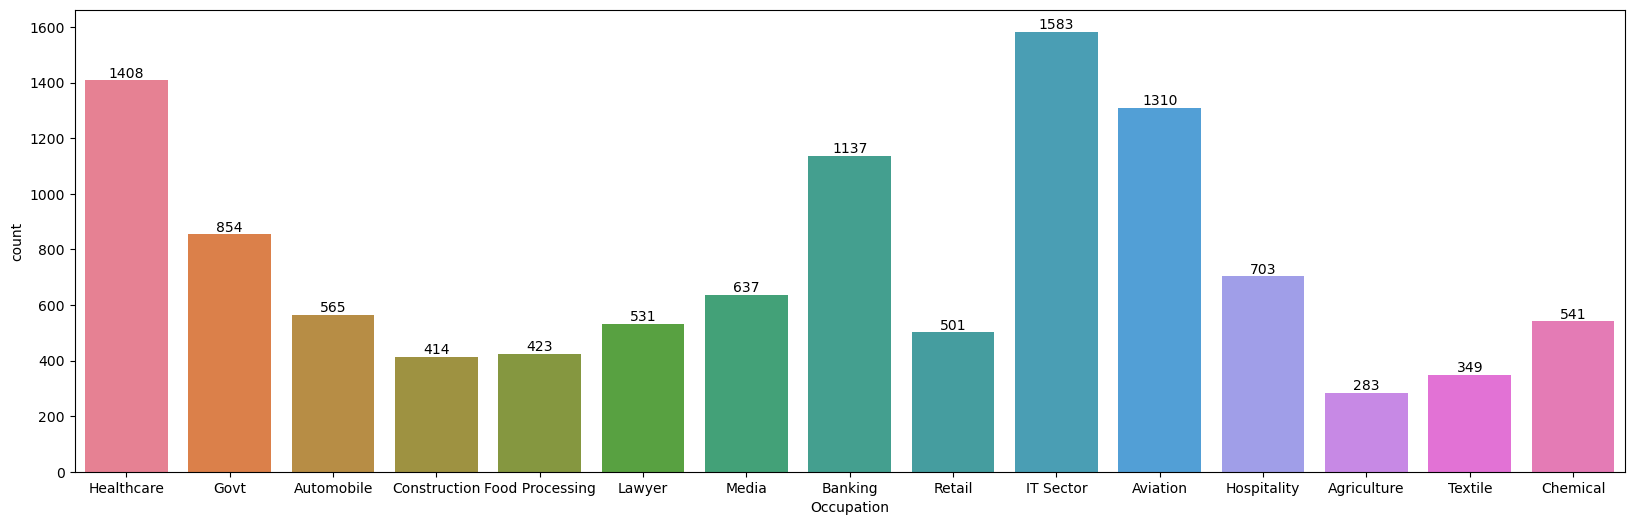

In [124]:
# Occupation Count
plt.figure(figsize=(20,6))
ax = sns.countplot(data=df,x='Occupation',hue = 'Occupation',palette = 'husl')

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Occupation', ylabel='Amount'>

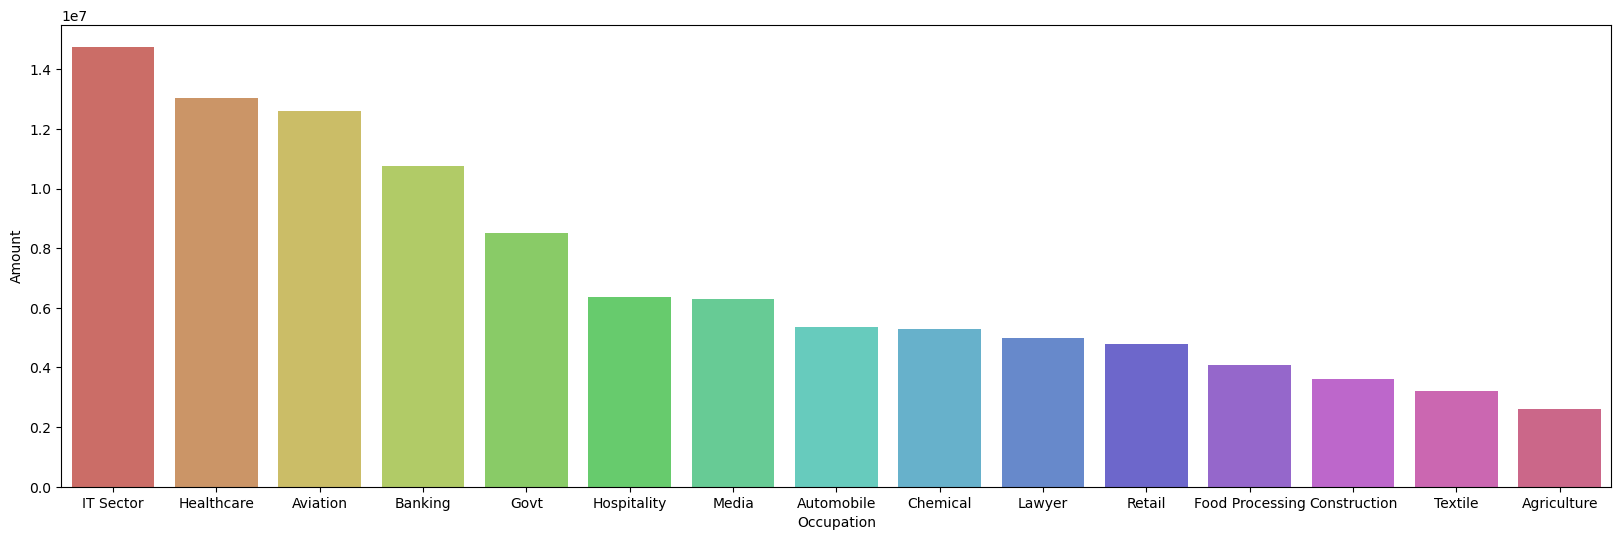

In [140]:
sales_AgeGroup = df.groupby(['Occupation'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)

# Plot of Amount Spent by Occupation

plt.figure(figsize=(20,6))
sns.barplot(data=sales_AgeGroup,x='Occupation',y='Amount',hue='Occupation',palette='hls')

*From above graphs we can see that most of the buyers are working in IT, Healthcare and Aviation sector*

## Product Category

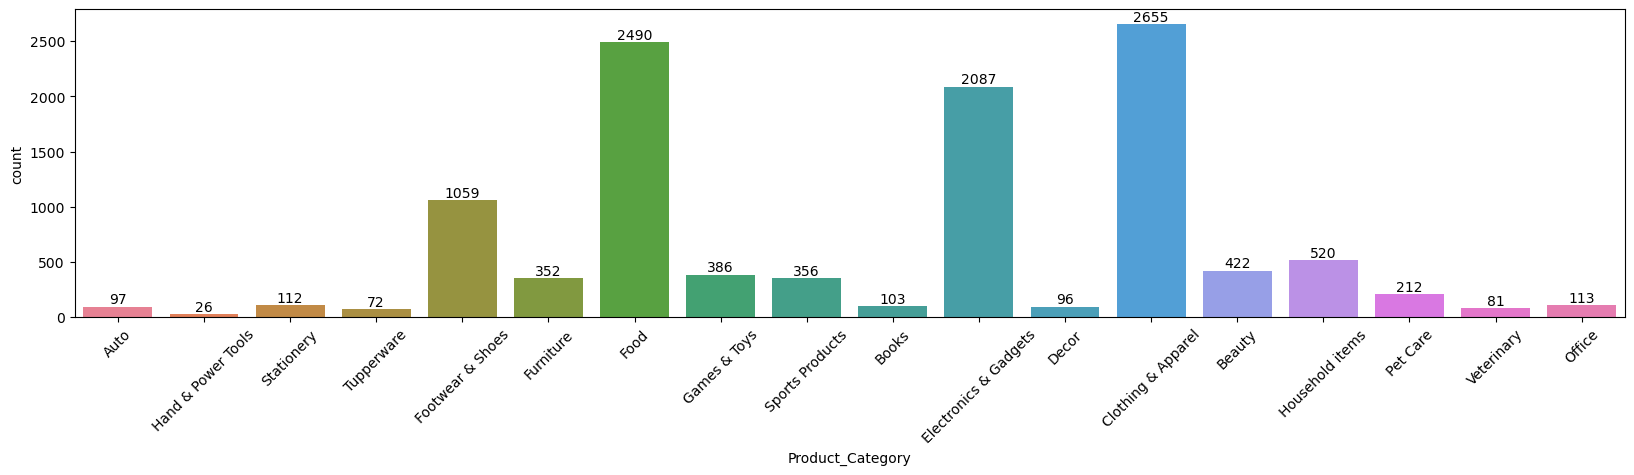

In [135]:
#Count of Product Category
plt.figure(figsize=(20,4))
ax = sns.countplot(data = df, x = 'Product_Category',hue='Product_Category',palette='husl')
plt.xticks(rotation=45)

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Product_Category', ylabel='Amount'>

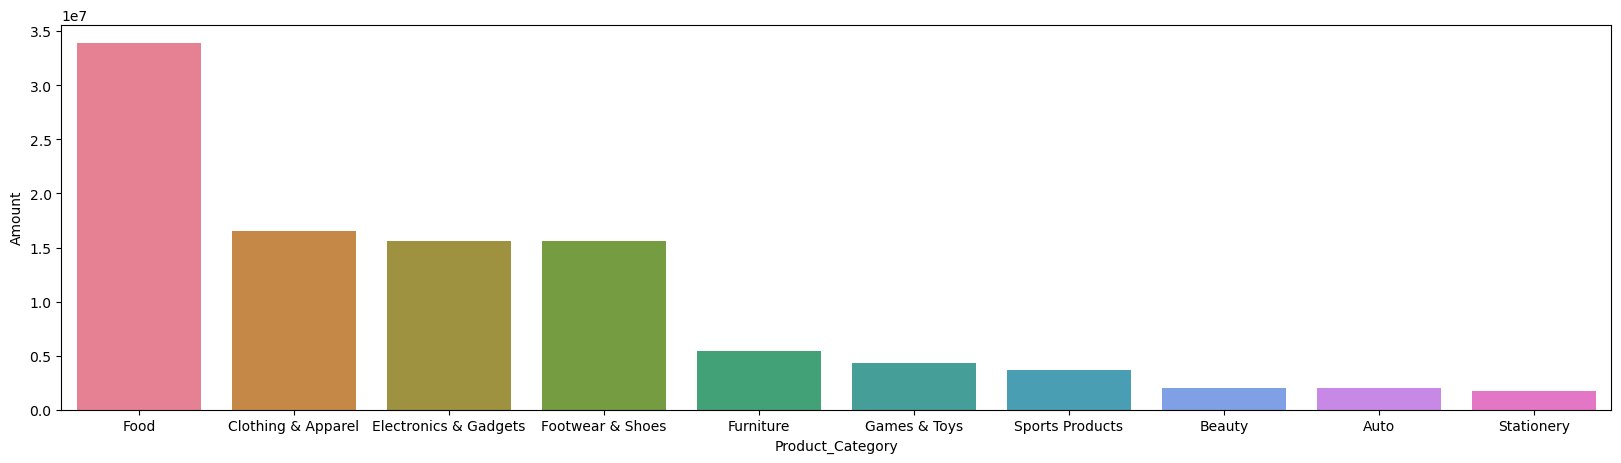

In [137]:
top_products = df.groupby(['Product_Category'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

#Plot of Amount Spent vs Products

plt.figure(figsize=(20,5))
sns.barplot(data = top_products, x = 'Product_Category',y= 'Amount',hue='Product_Category',palette='husl')

*From above graphs we can see that most of the sold products are from Food, Clothing and Electronics category*

## Conclusion:

#### Married women age group 26-35 yrs from UP, Maharastra and Karnataka working in IT, Healthcare and Aviation are more likely to buy products from Food, Clothing and Electronics category